# Artist tutorial ⭐ (read twice)

📄 Source: https://matplotlib.org/stable/tutorials/artists.html

Using Artist objects to render on the canvas. This is the page that explains *what* `fig` and `ax` really are.

## The three layers (the intro, before the first heading)

1. **`FigureCanvas`**: the area onto which the figure is drawn.
2. **`Renderer`**: the object that knows *how* to draw on the canvas.
3. **`Artist`**: the object that knows how to use a renderer to paint onto the canvas.

Canvas and Renderer talk to toolkits (wxPython, PostScript...). You spend ~95% of your time with **Artists**.

There are **two types of Artists**:

| Type | What it is | Examples |
| :-- | :-- | :-- |
| **Primitives** | the things we draw | `Line2D`, `Rectangle`, `Text`, `AxesImage` |
| **Containers** | places to put them | `Figure`, `Axes`, `Axis` |

The standard workflow: create a `Figure` → use it to create one or more `Axes` → use the Axes **helper methods** (`plot`, `text`, `hist`, `imshow`) to create the primitives (`Line2D`, `Text`, `Rectangle`, `AxesImage`).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print("matplotlib", mpl.__version__)

matplotlib 3.11.2


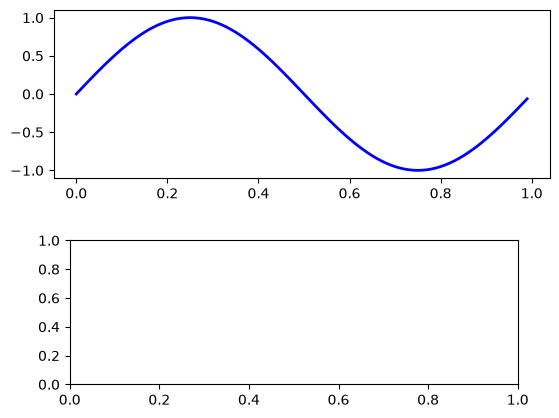

In [2]:
fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)   # two rows, one column, first plot

# An Axes at an arbitrary place: [left, bottom, width, height] in 0-1 figure coordinates
ax2 = fig.add_axes((0.15, 0.1, 0.7, 0.3))

t = np.arange(0.0, 1.0, 0.01)
s = np.sin(2*np.pi*t)
line, = ax.plot(t, s, color='blue', lw=2)   # plot() creates a Line2D and adds it to ax

`ax.plot` created a `Line2D` and added it to the Axes. `ax.lines` now holds that same object:

In [3]:
print(ax.lines[0])
print(line)
print(ax.lines[0] is line)   # True: the same object

Line2D(_child0)
Line2D(_child0)
True


In [4]:
# A line can be removed later with its remove() method
ax.lines[0].remove()
print(len(ax.lines))   # 0 lines left

0


The Axes also has helpers to decorate the x- and y-axis. `set_xlabel` returns a `Text` instance that lives on the `XAxis`:

In [5]:
xtext = ax.set_xlabel('my xdata')  # returns a Text instance
ytext = ax.set_ylabel('my ydata')
print(type(xtext), xtext is ax.xaxis.label)   # the label Text belongs to the XAxis

<class 'matplotlib.text.Text'> True


Every `Axes` contains an `XAxis` and a `YAxis`, which lay out and draw the ticks, tick labels and axis labels.

**Try creating the figure below** (the docs' example):

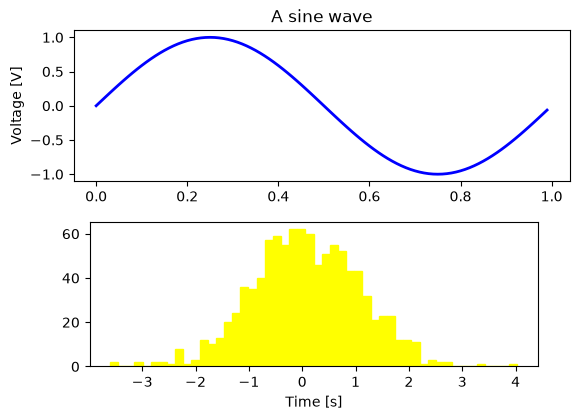

In [6]:
fig = plt.figure()
fig.subplots_adjust(top=0.8)
ax1 = fig.add_subplot(211)               # top half: a subplot
ax1.set_ylabel('Voltage [V]')
ax1.set_title('A sine wave')

t = np.arange(0.0, 1.0, 0.01)
s = np.sin(2*np.pi*t)
line, = ax1.plot(t, s, color='blue', lw=2)

# Fixing random state for reproducibility
np.random.seed(19680801)

ax2 = fig.add_axes((0.15, 0.1, 0.7, 0.3))   # bottom: an Axes placed by hand
n, bins, patches = ax2.hist(np.random.randn(1000), 50,
                            facecolor='yellow', edgecolor='yellow')
ax2.set_xlabel('Time [s]')

plt.show()

## Customizing your objects

Every element is an Artist with many properties. The Figure itself contains a `Rectangle` the size of the figure (`fig.patch`) for its background; each Axes has one too (`ax.patch`).

Properties every Artist has:

| Property | Description |
| :-- | :-- |
| alpha | transparency, 0-1 |
| animated | used for animated drawing |
| axes | the Axes the Artist lives in (maybe None) |
| clip_box / clip_on / clip_path | clipping settings |
| contains | a picking function |
| figure | the Figure the Artist lives in (maybe None) |
| label | a text label (used by legends) |
| picker | controls object picking |
| transform | the transformation (coordinate system) |
| visible | whether it is drawn |
| zorder | drawing order (higher = on top) |
| rasterized | turn vectors into raster graphics |

Each property has a **getter and setter**: `o.get_alpha()`, `o.set_alpha(0.5)`. Set several at once with `o.set(alpha=0.5, zorder=2)`.

0.4 4.0 2


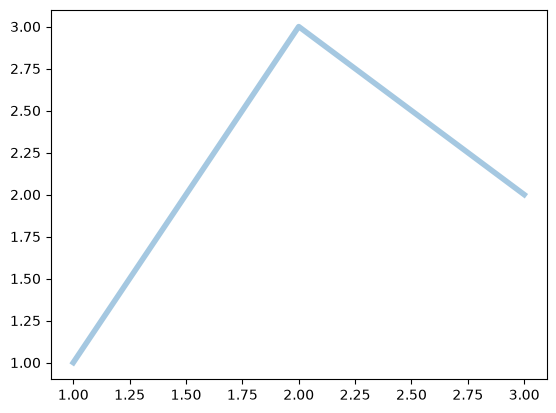

In [7]:
# Example: halve the alpha of a line, then set two properties at once
fig, ax = plt.subplots()
o, = ax.plot([1, 2, 3], [1, 3, 2], alpha=0.8)

a = o.get_alpha()
o.set_alpha(0.5*a)          # old-fashioned setter
o.set(lw=4, zorder=2)       # several properties in one call
print(o.get_alpha(), o.get_linewidth(), o.get_zorder())

`plt.getp(artist)` lists **all** properties of an artist and their values. Here are the properties of the Figure's background rectangle:

In [8]:
plt.getp(fig.patch)

    agg_filter = None
    alpha = None
    angle = 0.0
    animated = False
    antialiased or aa = False
    bbox = Bbox(x0=0.0, y0=0.0, x1=1.0, y1=1.0)
    capstyle = butt
    center = [0.5 0.5]
    children = []
    clip_box = None
    clip_on = True
    clip_path = None
    corners = [[0. 0.]  [1. 0.]  [1. 1.]  [0. 1.]]
    data_transform = BboxTransformTo(     TransformedBbox(         Bbox...
    edgecolor or ec = (1.0, 1.0, 1.0, 1.0)
    edgegapcolor = None
    extents = Bbox(x0=0.0, y0=0.0, x1=640.0, y1=480.0)
    facecolor or fc = (1.0, 1.0, 1.0, 1.0)
    figure = Figure(640x480)
    fill = True
    gid = None
    hatch = None
    hatch_linewidth = 1.0
    hatchcolor = (1.0, 1.0, 1.0, 1.0)
    height = 1
    in_layout = False
    joinstyle = miter
    label = 
    linestyle or ls = solid
    linewidth or lw = 0.0
    mouseover = False
    patch_transform = CompositeGenericTransform(     BboxTransformTo(   ...
    path = Path(array([[0., 0.],        [1., 0.],        [1.,...
    

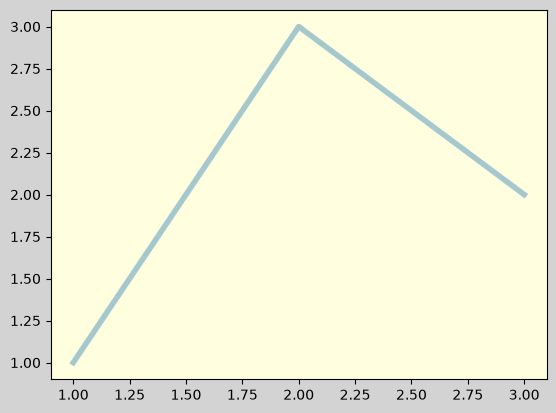

In [9]:
# The patches are real Artists: recolour the figure and Axes backgrounds
fig.patch.set_facecolor('lightgrey')
ax.patch.set_facecolor('lightyellow')
fig

## Object containers

Primitives are what you usually want to configure (a Text's font, a Line2D's width). Containers hold them, and also have their own properties (e.g. the Axes' `xscale`). This section is about **where each container stores its Artists**, so you know how to reach them.

### Figure container

The top-level container. Its background is `fig.patch`. Axes you add with `add_subplot` / `add_axes` are appended to `fig.axes`.

Axes(0.125,0.53;0.775x0.35)
[<Axes: >, <Axes: >]


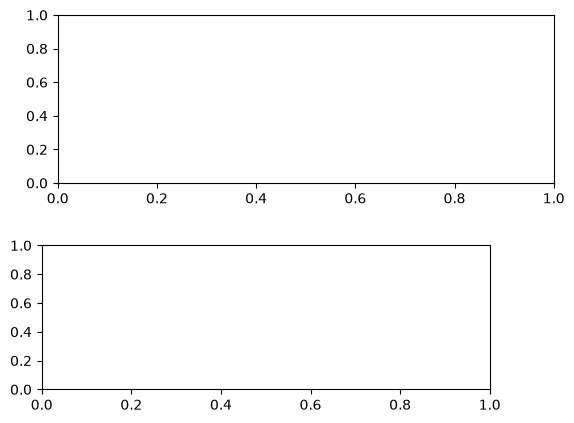

In [10]:
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_axes((0.1, 0.1, 0.7, 0.3))
print(ax1)
print(fig.axes)

Don't add/remove Axes from `fig.axes` directly. Use `add_subplot` / `add_axes`, and `ax.remove()` to delete. Looping over it is fine:

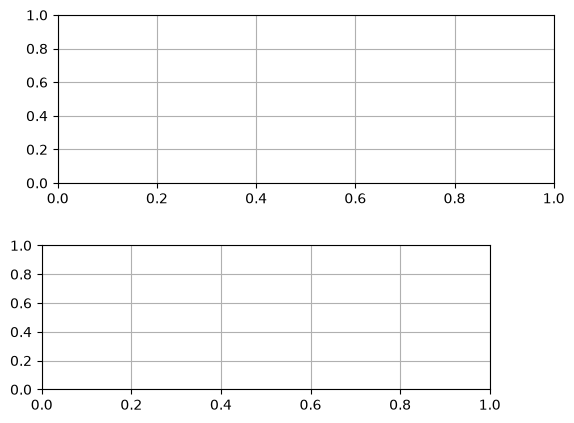

In [11]:
for ax in fig.axes:
    ax.grid(True)   # turn on the grid in every Axes of the figure
fig

The Figure also has its own `images`, `lines`, `patches` and `texts` lists. Artists added there use **pixels** by default. With Figure-level methods (e.g. `fig.text`) the default is **figure coordinates**: (0, 0) bottom-left, (1, 1) top-right.
You can choose the coordinate system yourself with `transform=fig.transFigure`:

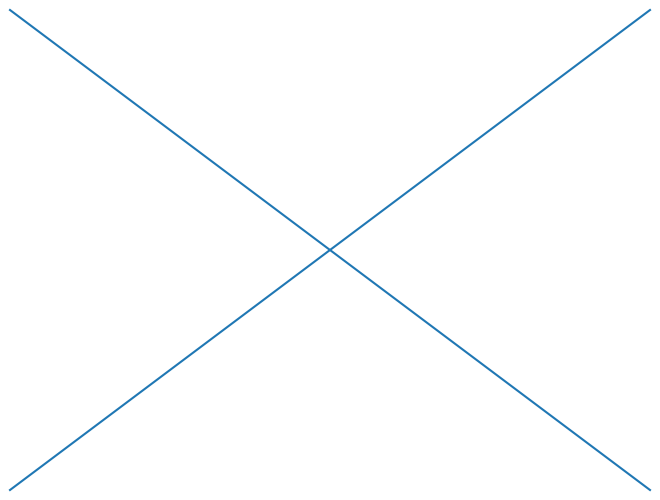

In [12]:
import matplotlib.lines as lines

fig = plt.figure()

# two diagonal lines in figure coordinates (0..1 across the whole figure)
l1 = lines.Line2D([0, 1], [0, 1], transform=fig.transFigure, figure=fig)
l2 = lines.Line2D([0, 1], [1, 0], transform=fig.transFigure, figure=fig)
fig.lines.extend([l1, l2])

plt.show()

Summary of what the Figure contains:

| Figure attribute | Description |
| :-- | :-- |
| axes | a list of `Axes` instances |
| patch | the `Rectangle` background |
| images | a list of `FigureImage` patches (raw pixel display) |
| legends | a list of Figure `Legend` instances (different from `Axes.get_legend()`) |
| lines | a list of Figure `Line2D` instances (rarely used, see `Axes.lines`) |
| patches | a list of Figure `Patch`es (rarely used, see `Axes.patches`) |
| texts | a list of Figure `Text` instances |

### Axes container ⭐

The center of the Matplotlib universe. It holds most Artists, has helpers to create them and to reach them. Its `patch` is a `Rectangle` (or a `Circle` for polar axes) that sets the shape, background and border of the plotting region.

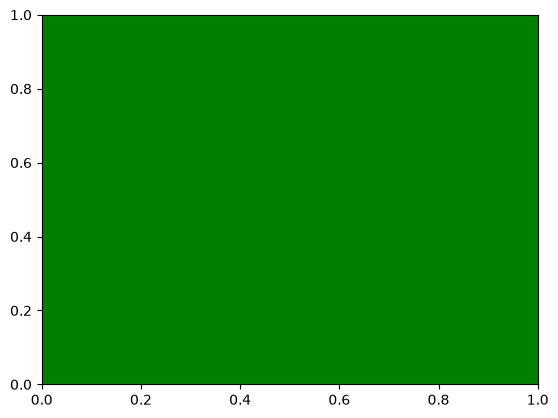

In [13]:
fig = plt.figure()
ax = fig.add_subplot()
rect = ax.patch  # a Rectangle instance
rect.set_facecolor('green')

A plotting method creates the artist, adds it to the right list on the Axes, and returns it:

<Axes.ArtistList of 1 lines>


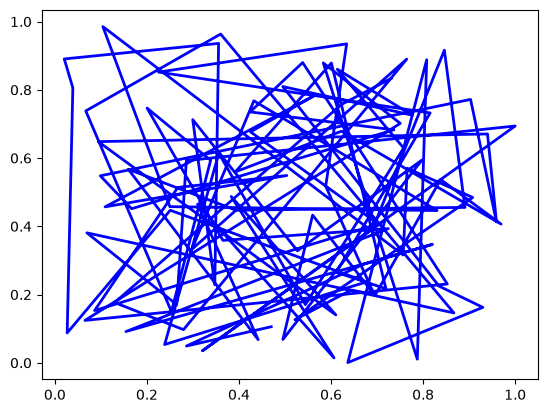

In [14]:
fig, ax = plt.subplots()
x, y = np.random.rand(2, 100)
line, = ax.plot(x, y, '-', color='blue', linewidth=2)   # plot returns a LIST of lines, we unpack the one line
print(ax.lines)

In [15]:
# Methods that create patches add them to ax.patches
n, bins, rectangles = ax.hist(np.random.randn(1000), 50)
print(rectangles)          # a BarContainer of 50 Rectangle artists
print(len(ax.patches))     # 50

<BarContainer object of 50 artists>
50


Don't append to `ax.lines` / `ax.patches` yourself. When the Axes adds an object it also:

- sets the Artist's `figure` and `axes` properties,
- sets the default Axes transformation (data coordinates),
- updates the data limits used for **autoscaling**.

You *can* create objects yourself and add them with `ax.add_line` / `ax.add_patch`. The docs walk through what happens:

axes before: None
transform before: IdentityTransform()
axes after: Axes(0.125,0.11;0.775x0.77)
uses transData: True


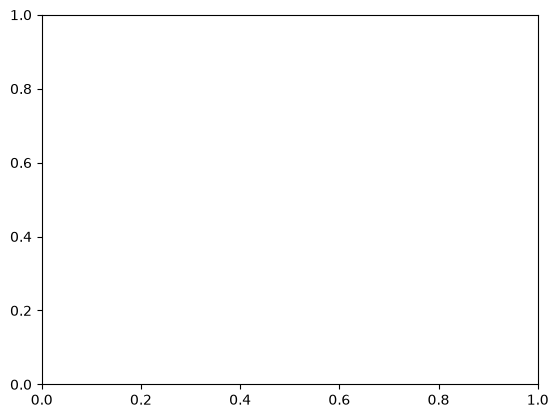

In [16]:
import matplotlib.patches

fig, ax = plt.subplots()

# create a rectangle instance
rect = matplotlib.patches.Rectangle((1, 1), width=5, height=12)

# by default the Axes instance is None
print("axes before:", rect.axes)

# and the transformation is the identity transform
print("transform before:", rect.get_data_transform())

# now we add the Rectangle to the Axes
ax.add_patch(rect)

# notice that ax.add_patch has set the Axes instance...
print("axes after:", rect.axes)
# ...and the transformation is now ax.transData (data coordinates)
print("uses transData:", rect.get_data_transform() == ax.transData)

In [17]:
# the x limits of the Axes have not changed yet
print(ax.get_xlim())

# but the data limits have been updated to include the rectangle
print(ax.dataLim.bounds)

# we can manually run the autoscaling machinery
ax.autoscale_view()

# and now the x limits include the rectangle, plus margins
print(ax.get_xlim())

(np.float64(0.0), np.float64(1.0))
(np.float64(1.0), np.float64(1.0), np.float64(5.0), np.float64(12.0))
(np.float64(0.75), np.float64(6.25))


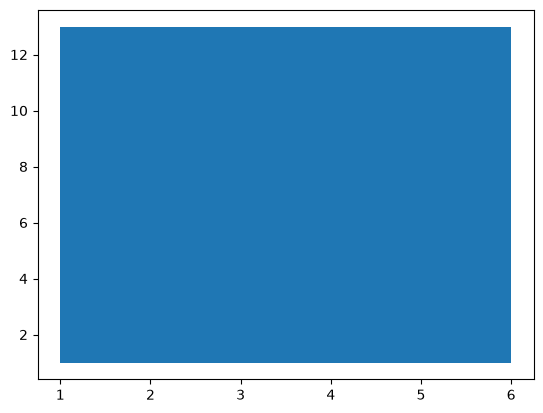

In [18]:
fig   # show the figure with the rectangle now in view

Axes helper methods, the Artist each creates, and where it is stored:

| Axes helper method | Artist | Container |
| :-- | :-- | :-- |
| `annotate` - text annotations | `Annotation` | `ax.texts` |
| `bar` - bar charts | `Rectangle` | `ax.patches` |
| `errorbar` - error bar plots | `Line2D` and `Rectangle` | `ax.lines` and `ax.patches` |
| `fill` - shared area | `Polygon` | `ax.patches` |
| `hist` - histograms | `Rectangle` | `ax.patches` |
| `imshow` - image data | `AxesImage` | `ax.images` |
| `legend` - Axes legend | `Legend` | `ax.get_legend()` |
| `plot` - xy plots | `Line2D` | `ax.lines` |
| `scatter` - scatter charts | `PolyCollection` | `ax.collections` |
| `text` - text | `Text` | `ax.texts` |

The Axes also holds two important containers: `ax.xaxis` (`XAxis`) and `ax.yaxis` (`YAxis`). Many Axes helpers forward to them, so you rarely need them directly. For example:

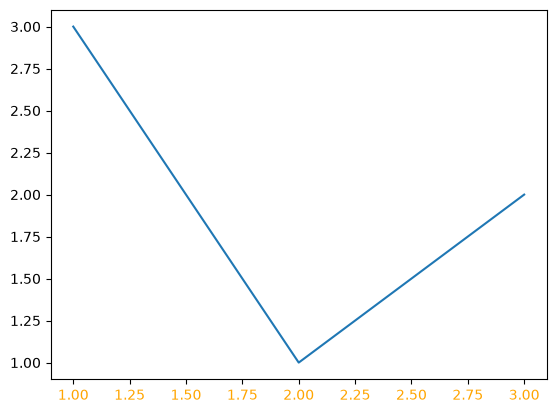

In [19]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [3, 1, 2])
ax.tick_params(axis='x', labelcolor='orange')   # Axes helper -> forwarded to the XAxis tick labels

Summary of what the Axes contains:

| Axes attribute | Description |
| :-- | :-- |
| artists | an `ArtistList` of `Artist` instances |
| patch | `Rectangle` instance for the Axes background |
| collections | an `ArtistList` of `Collection` instances |
| images | an `ArtistList` of `AxesImage` |
| lines | an `ArtistList` of `Line2D` instances |
| patches | an `ArtistList` of `Patch` instances |
| texts | an `ArtistList` of `Text` instances |
| xaxis | a `matplotlib.axis.XAxis` instance |
| yaxis | a `matplotlib.axis.YAxis` instance |

The legend is reached with `ax.get_legend()`.

### Axis containers

An `Axis` draws the tick lines, grid lines, tick labels and the axis label. It also stores the data and view intervals used for autoscaling/panning/zooming, and the `Locator` (where ticks go) and `Formatter` (how they read).

Each Axis has a `label` attribute (what `set_xlabel` changes) and lists of major and minor ticks. Ticks are created dynamically, so don't edit them one by one: use **locators, formatters and `tick_params`**.

Useful accessors (most have a matching setter):

| Axis accessor | Description |
| :-- | :-- |
| `get_scale` | the scale, e.g. 'log' or 'linear' |
| `get_view_interval` | the view limits |
| `get_data_interval` | the data limits |
| `get_label` | the axis label, a `Text` instance |
| `get_major_locator` / `get_minor_locator` | the `Locator` for major / minor ticks |
| `get_major_formatter` / `get_minor_formatter` | the `Formatter` for major / minor ticks |
| `get_tick_params` | styling of ticks, tick labels and grid lines |
| `grid` | turn the grid on/off for major or minor ticks |

scale:           linear
view interval:   [-0.45  9.45]
data interval:   [0. 9.]
label:           ''
major locator:   <matplotlib.ticker.AutoLocator object at 0x7f90226862d0>
major formatter: <matplotlib.ticker.ScalarFormatter object at 0x7f902264e3d0>


tick labels:     ['−2', '0', '2', '4', '6', '8', '10']


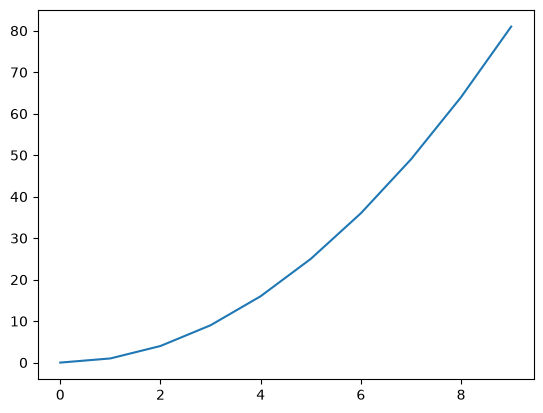

In [20]:
fig, ax = plt.subplots()
ax.plot(np.arange(10), np.arange(10)**2)
axis = ax.xaxis

print("scale:          ", axis.get_scale())
print("view interval:  ", axis.get_view_interval())
print("data interval:  ", axis.get_data_interval())
print("label:          ", repr(axis.get_label().get_text()))
print("major locator:  ", axis.get_major_locator())
print("major formatter:", axis.get_major_formatter())
print("tick labels:    ", [t.get_text() for t in axis.get_ticklabels()])

## Exercise (from the README)

Make a chart, then use **only** `get_*` / `set_*` on the objects in `ax.patches`, `ax.spines` and `ax.xaxis` to:
1. recolour one bar,
2. hide the top and right spines,
3. rotate the tick labels.

patches: 5 | tallest bar height: 6


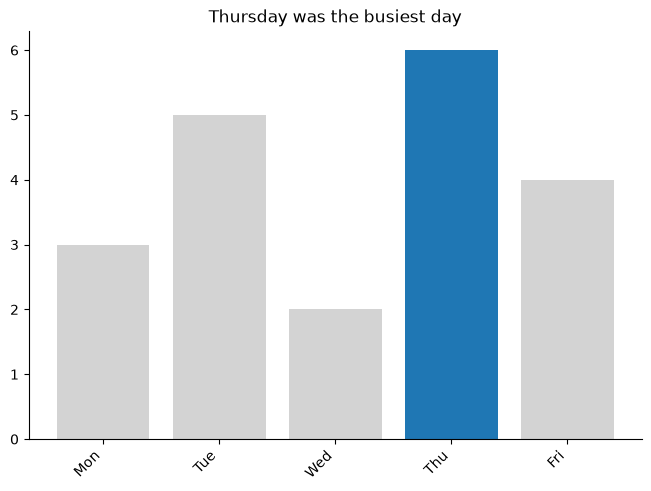

In [21]:
fig, ax = plt.subplots(layout="constrained")
ax.bar(["Mon", "Tue", "Wed", "Thu", "Fri"], [3, 5, 2, 6, 4], color="lightgrey")

# 1. recolour one bar: bars are Rectangle artists stored in ax.patches
tallest = max(ax.patches, key=lambda r: r.get_height())   # find the tallest bar with a getter
tallest.set_facecolor("tab:blue")                          # and recolour it with a setter

# 2. hide two spines: ax.spines is a dict-like of Spine artists
ax.spines[["top", "right"]].set_visible(False)

# 3. rotate the tick labels: they are Text artists owned by the XAxis
for label in ax.xaxis.get_ticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment("right")

ax.set_title("Thursday was the busiest day")
print("patches:", len(ax.patches), "| tallest bar height:", tallest.get_height())

## Key takeaways

- **Canvas → Renderer → Artist.** You work with Artists.
- **Primitives** (Line2D, Rectangle, Text...) live inside **containers** (Figure → Axes → Axis).
- Every Artist has `get_*` / `set_*` and `.set(...)`; `plt.getp(obj)` lists everything.
- Helper methods create artists and store them: `plot` → `ax.lines`, `bar`/`hist` → `ax.patches`, `scatter` → `ax.collections`, `text`/`annotate` → `ax.texts`, `imshow` → `ax.images`.
- Ticks: use locators, formatters and `tick_params`, not individual tick objects.